# WRF Idealized Run — Quarter-Circle Supercell (real model output)

**Runnable companion to [`wrf-model-guide.md`](../wrf-model-guide.md) §14
(Idealized Runs).**

Unlike a full real-data forecast, WRF's **idealized test cases** compile and run
on a workstation in minutes with *no external data* — they are the honest
"actually run the model" example. This notebook visualises **real output** from
the `em_quarter_ss` quarter-circle shear supercell case, run on a build of
WRF v4.7.1:

```
$ cd WRFV4.7.1/test/em_quarter_ss
$ ./ideal.exe          # builds wrfinput from input_sounding  →  SUCCESS COMPLETE IDEAL INIT
$ OMP_NUM_THREADS=8 ./wrf.exe      # →  SUCCESS COMPLETE WRF
```

Run facts (this output): 30-min simulation, Δt = 12 s (150 steps), 119×119×40
grid at Δx = 1 km, ~16 min wall on 8 OpenMP threads, peak RSS ≈ 680 MB,
6 history frames every 6 min. The full `wrfout` is ~46 MB; committed here is a
compact extract (column-max updraft, accumulated rain, a vertical W section).

> **Idealized ≠ real-data:** there is no geography, so `XLAT/XLONG` are zero and
> surface diagnostics (`T2`, 10-m wind) are inactive — a supercell is judged by
> its **updraft, reflectivity, and rain**, which is exactly what we plot. For a
> surface-field workflow on a *real-data* run, see
> [`wrf_postprocessing.ipynb`](wrf_postprocessing.ipynb).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

ds = xr.open_dataset(sampledata.wrf_idealized_path())
dx_km = ds.attrs["DX"] / 1000.0
times = ds.attrs["times"].split(";")
nx = ds.sizes["west_east"]
x = np.arange(nx) * dx_km           # km
plt.rcParams["figure.dpi"] = 110
print("frames:", times)
ds

frames: ['0001-01-01_00:00:00', '0001-01-01_00:06:00', '0001-01-01_00:12:00', '0001-01-01_00:18:00', '0001-01-01_00:24:00', '0001-01-01_00:30:00']


<xarray.Dataset> Size: 794kB
Dimensions:      (Time: 6, south_north: 119, west_east: 119, bottom_top: 40)
Dimensions without coordinates: Time, south_north, west_east, bottom_top
Data variables:
    max_updraft  (Time, south_north, west_east) float32 340kB ...
    rain         (Time, south_north, west_east) float32 340kB ...
    w_xsec       (Time, bottom_top, west_east) float32 114kB ...
Attributes:
    title:     Compact real WRF em_quarter_ss output (idealized supercell)
    source:    WRFV4.7.1 em_quarter_ss 30-min sim dt=12s 8 OpenMP threads
    DX:        2000.0
    xsec_row:  59
    times:     0001-01-01_00:00:00;0001-01-01_00:06:00;0001-01-01_00:12:00;00...

## 1 · The supercell at maturity

Two diagnostics at the final frame: **column-maximum updraft** (the rotating
storm core) and **accumulated precipitation** (the rain swath left behind).
Distances are in km on the idealized grid (no map projection).

peak updraft = 30.4 m/s   |   max accumulated rain = 7.9 mm


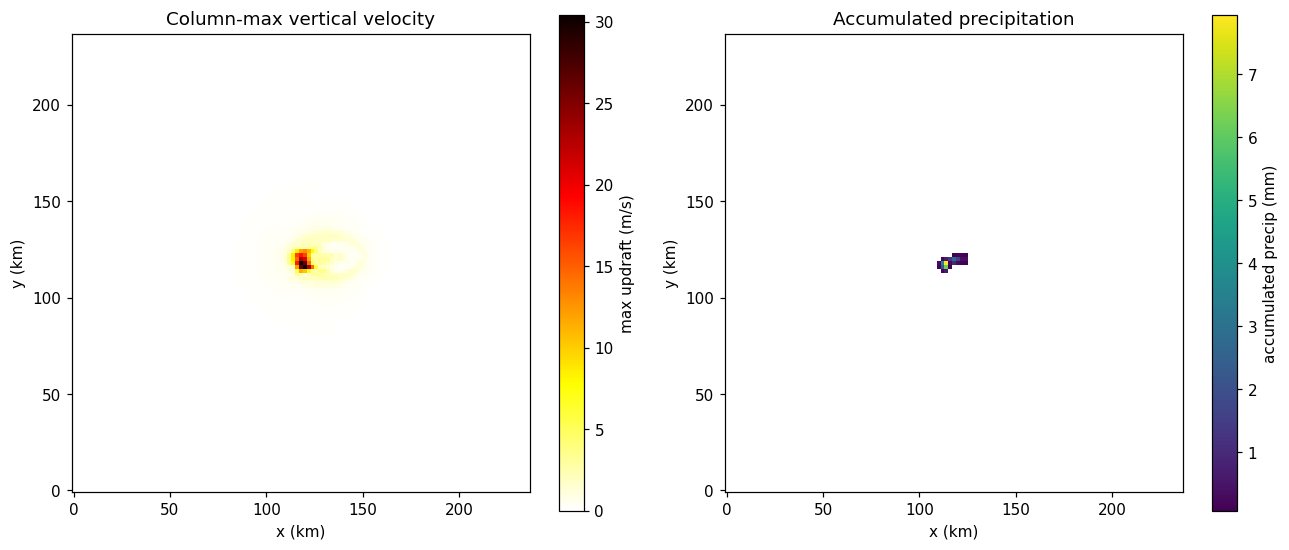

In [2]:
w = ds["max_updraft"].isel(Time=-1).values
rain = ds["rain"].isel(Time=-1).values

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
pcm1 = a1.pcolormesh(x, x, w, cmap="hot_r", shading="auto")
plt.colorbar(pcm1, ax=a1, label="max updraft (m/s)")
a1.set(xlabel="x (km)", ylabel="y (km)", title="Column-max vertical velocity")

pcm2 = a2.pcolormesh(x, x, np.ma.masked_less(rain, 0.05), cmap="viridis", shading="auto")
plt.colorbar(pcm2, ax=a2, label="accumulated precip (mm)")
a2.set(xlabel="x (km)", ylabel="y (km)", title="Accumulated precipitation")
for a in (a1, a2):
    a.set_aspect("equal")
plt.tight_layout()
print(f"peak updraft = {w.max():.1f} m/s   |   max accumulated rain = {rain.max():.1f} mm")

## 2 · Vertical structure of the updraft

A west–east vertical cross-section of `W` through the row of peak updraft shows
the deep, upright supercell updraft core (positive) flanked by compensating
downdrafts (negative).

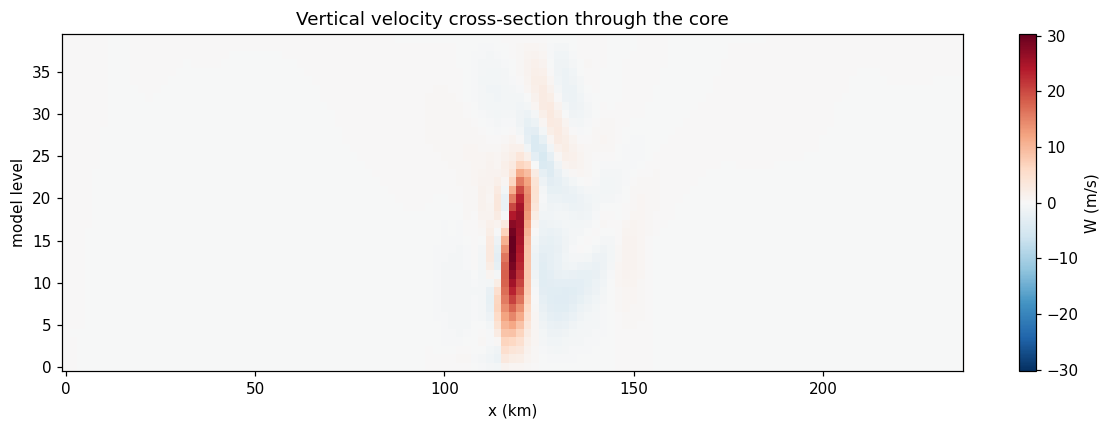

In [3]:
wx = ds["w_xsec"].isel(Time=-1).values        # (bottom_top, west_east)
nz = wx.shape[0]
fig, ax = plt.subplots(figsize=(11, 4))
lim = np.abs(wx).max()
pcm = ax.pcolormesh(x, np.arange(nz), wx, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
plt.colorbar(pcm, label="W (m/s)")
ax.set(xlabel="x (km)", ylabel="model level", title="Vertical velocity cross-section through the core")
plt.tight_layout()

## 3 · Storm intensification over time

Peak updraft and total rainfall grow as the supercell organises across the 30-minute run.

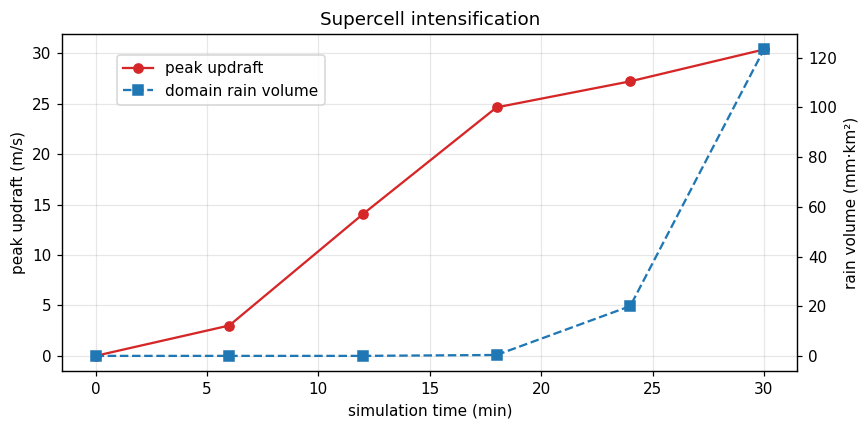

In [4]:
peak_w = ds["max_updraft"].max(dim=["south_north", "west_east"]).values
total_rain = ds["rain"].sum(dim=["south_north", "west_east"]).values * (dx_km ** 2)  # mm·km²
mins = np.arange(len(peak_w)) * 6

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(mins, peak_w, "o-", color="C3", label="peak updraft")
ax1.set(xlabel="simulation time (min)", ylabel="peak updraft (m/s)")
ax2 = ax1.twinx()
ax2.plot(mins, total_rain, "s--", color="C0", label="domain rain volume")
ax2.set_ylabel("rain volume (mm·km²)")
ax1.set_title("Supercell intensification"); ax1.grid(alpha=0.3)
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.88)); plt.tight_layout()

---
### Reproduce this run yourself
```bash
# build once (this output used the NVIDIA HPC SDK, OpenMP):
cd WRFV4.7.1 && ./configure   # pick a serial/smpar option, em_quarter_ss is small
./compile em_quarter_ss >& compile.log

cd test/em_quarter_ss
# default runs 2 min; for a developed storm set run_minutes=30, history_interval=6
./ideal.exe
OMP_NUM_THREADS=8 ./wrf.exe
```
Other quick idealized cases worth trying: `em_les` (large-eddy), `em_b_wave`
(baroclinic wave), `em_seabreeze2d_x`. See the guide's idealized-run section.